In [1]:
# Importing necessary libraries for data preprocessing
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Importing necessary libraries for building and evaluating models
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
from tensorflow.keras.losses import KLDivergence, MeanSquaredError

# Importing necessary libraries for saving and loading models
import joblib

In [2]:
df = pd.read_csv('KDDTrain+.txt', header=None)

In [3]:
pd.set_option('display.max_columns',None)

In [4]:
df[41].unique()

array(['normal', 'neptune', 'warezclient', 'ipsweep', 'portsweep',
       'teardrop', 'nmap', 'satan', 'smurf', 'pod', 'back',
       'guess_passwd', 'ftp_write', 'multihop', 'rootkit',
       'buffer_overflow', 'imap', 'warezmaster', 'phf', 'land',
       'loadmodule', 'spy', 'perl'], dtype=object)

In [5]:
#converting into five category 

df.replace(to_replace=["back", "neptune","pod", "smurf", "teardrop", "land"],
            value= "Dos", inplace= True)

df.replace(to_replace=["satan", "ipsweep","nmap", "portsweep"],
            value= "Probe", inplace= True)

df.replace(to_replace=["guess_passwd", "ftp_write","multihop", "imap", "warezmaster","phf", "spy", "warezclient"],
            value= "R2L", inplace= True)

df.replace(to_replace=["buffer_overflow", "rootkit","loadmodule", "perl"],
            value= "U2R", inplace= True)

In [6]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove(41)

In [7]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove(42)  # removing additional info column

In [8]:
# Define preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)])

In [9]:
# Applying ColumnTransformer
df_processed = preprocessor.fit_transform(df.drop(columns=[41, 42]))
df_processed = pd.DataFrame(df_processed)

In [10]:
# Convert the target column to numeric
le = LabelEncoder()
df[41] = le.fit_transform(df[41])

In [11]:
# Extract target variable
y = df[41].values

In [12]:
# Check shape of preprocessed data
df_processed.shape, y.shape

((125973, 122), (125973,))

In [13]:
# Set random seed for reproducibility 
np.random.seed(42)
tf.random.set_seed(42)

In [14]:
# Define the dimensionality of the bottleneck for each autoencoder
bottleneck_dims = [64, 32, 16, 8]

In [15]:
# Store the models and their encoders
autoencoders = []
encoders = []

In [16]:
weight_decay = 0.001
learning_rate = 0.005

In [17]:
# Define the sparsity parameter and target sparsity
sparsity_target = 0.06
sparsity_weight = 0.1

mse_loss = MeanSquaredError()
kl_loss = KLDivergence()

def custom_loss(y_true, y_pred):
    # Calculate the MSE loss
    mse = mse_loss(y_true, y_pred)

    # Calculate the average activation of the bottleneck layer
    avg_activation = K.mean(y_pred, axis=0)

    # Calculate the KL Divergence for the sparsity constraint
    kl = K.sum(sparsity_target * K.log(sparsity_target / avg_activation) +
               (1 - sparsity_target) * K.log((1 - sparsity_target) / (1 - avg_activation)))

    # Combine the MSE and KL Divergence losses
    return mse + sparsity_weight * kl

In [18]:
def autoencoder_model(bottleneck_dims):
    autoencoder = Sequential([
        Dense(64, activation = 'relu', input_shape=(df_processed.shape[1],)),
        Dense(bottleneck_dims, activation = 'relu'),
        Dense(df_processed.shape[1], activation = 'sigmoid')
    ])
    
    return autoencoder

# Define and train the autoencoders
for i, bottleneck_dim in enumerate(bottleneck_dims):

    print(f"Training {i+1} autoencoder model")
    # Define the autoencoder
    autoencoder = autoencoder_model(bottleneck_dim)
    
    # Compile the autoencoder
    autoencoder.compile(optimizer = Adam(learning_rate = learning_rate, decay = weight_decay), loss = custom_loss)
    
    # Train the autoencoder
    history = autoencoder.fit(df_processed, df_processed, epochs = 10, batch_size = 256, verbose = 1)
    
    # Define the encoder
    encoder = Sequential(autoencoder.layers[:2])
    
    # Save the autoencoder and encoder
    autoencoders.append(autoencoder)
    encoders.append(encoder)
    
    # Update df_processed for the next autoencoder
    df_processed = encoder.predict(df_processed)
    print("\n")

Training 1 autoencoder model
Epoch 1/10
493/493 [==============================] - 2s 4ms/step - loss: 0.1421
Epoch 2/10
493/493 [==============================] - 1s 3ms/step - loss: 0.0497
Epoch 3/10
493/493 [==============================] - 1s 3ms/step - loss: 0.0472
Epoch 4/10
493/493 [==============================] - 1s 3ms/step - loss: 0.0460
Epoch 5/10
493/493 [==============================] - 2s 3ms/step - loss: 0.0452
Epoch 6/10
493/493 [==============================] - 1s 3ms/step - loss: 0.0449
Epoch 7/10
493/493 [==============================] - 1s 3ms/step - loss: 0.0447
Epoch 8/10
493/493 [==============================] - 1s 3ms/step - loss: 0.0445
Epoch 9/10
493/493 [==============================] - 1s 3ms/step - loss: 0.0442
Epoch 10/10
493/493 [==============================] - 1s 3ms/step - loss: 0.0442


Training 2 autoencoder model
Epoch 1/10
493/493 [==============================] - 2s 2ms/step - loss: 1.1011
Epoch 2/10
493/493 [============================

In [19]:
df_processed = pd.DataFrame(df_processed)
df_processed

,0,1,2,3,4,5,6,7
0,0.0,96.946533,93.669128,0.0,0.0,0.0,0.0,45.542259
1,0.0,36.464237,160.200317,0.0,0.0,0.0,0.0,53.202629
2,0.0,26.985447,52.777084,0.0,0.0,0.0,0.0,0.000000
3,0.0,31.156527,3.446887,0.0,0.0,0.0,0.0,32.910351
4,0.0,32.464699,0.000000,0.0,0.0,0.0,0.0,35.360065
...,...,...,...,...,...,...,...,...
125968,0.0,27.188700,53.313938,0.0,0.0,0.0,0.0,0.000000
125969,0.0,22.694988,101.263977,0.0,0.0,0.0,0.0,32.057209
125970,0.0,59.532761,58.681995,0.0,0.0,0.0,0.0,124.602592
125971,0.0,7.414721,46.886684,0.0,0.0,0.0,0.0,81.952538


In [20]:
# Now, df_processed is the output from the last encoder. We can use this to train our XGBoost model.
X_train, X_test, y_train, y_test = train_test_split(df_processed, y, test_size=0.2, random_state=42)

***

In [21]:
# Hyperparameter tuning for LGBM Classifier using GridSearchCV
# Number of trees 
n_estimators = [int(x) for x in np.linspace(start = 80, stop = 1000, num = 5)]

# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(10, 50, 3)]

# Maximum number of leaves in tree
num_leaves = [int(x) for x in np.linspace(8, 500, 4)]

# Learning rate
learning_rate = [0.01, 0.255]

# Create the random grid
param_grid = {'n_estimators': n_estimators,
              'max_depth': max_depth,
              'num_leaves' : num_leaves,
              'learning_rate' : learning_rate
              }

print(param_grid)

{'n_estimators': [80, 310, 540, 770, 1000], 'max_depth': [10, 30, 50], 'num_leaves': [8, 172, 336, 500], 'learning_rate': [0.01, 0.255]}


In [22]:
# Intialize the LGBM model 
lgbm = LGBMClassifier(objective = 'multiclass', metric = 'multi_logloss', num_classes = 5)

# Perform grid search with cross-validation
lgbm_gridcv = GridSearchCV(estimator = lgbm ,param_grid = param_grid, cv=3, verbose=3, n_jobs = -1)

### fit the grid searched model
%time lgbm_gridcv.fit(X_train,y_train)

Fitting 3 folds for each of 120 candidates, totalling 360 fits
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002655 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 3
[LightGBM] [Info] Start training from score -1.008891
[LightGBM] [Info] Start training from score -2.383013
[LightGBM] [Info] Start training from score -4.872987
[LightGBM] [Info] Start training from score -7.807103
[LightGBM] [Info] Start training from score -0.625400
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

GridSearchCV(cv=3,
             estimator=LGBMClassifier(metric='multi_logloss', num_classes=5,
                                      objective='multiclass'),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.255],
                         'max_depth': [10, 30, 50],
                         'n_estimators': [80, 310, 540, 770, 1000],
                         'num_leaves': [8, 172, 336, 500]},
             verbose=3)

In [23]:
# save the model to a file
joblib.dump(lgbm_gridcv, 'lgbm_gridseachcv_five_sparse_0.06.joblib')

['lgbm_gridseachcv_five_sparse_0.06.joblib']

In [24]:
# print best parameter after tuning 
print(lgbm_gridcv.best_params_) 

# Get the best estimator
best_gridcv = lgbm_gridcv.best_estimator_

{'learning_rate': 0.01, 'max_depth': 30, 'n_estimators': 1000, 'num_leaves': 172}


In [21]:
# Intialize the LGBM model 
lgbm_best = LGBMClassifier(objective = 'multiclass', metric = 'multi_logloss', num_classes = 5, 
                      learning_rate = 0.01, max_depth = 30, n_estimators = 1000, num_leaves = 172)

### fit the grid searched model
%time lgbm_best.fit(X_train,y_train)

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005696 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 3
[LightGBM] [Info] Start training from score -1.008891
[LightGBM] [Info] Start training from score -2.383013
[LightGBM] [Info] Start training from score -4.872987
[LightGBM] [Info] Start training from score -7.807103
[LightGBM] [Info] Start training from score -0.625400
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

LGBMClassifier(learning_rate=0.01, max_depth=30, metric='multi_logloss',
               n_estimators=1000, num_classes=5, num_leaves=172,
               objective='multiclass')

****

In [22]:
# Prediction on test dataset
%time y_pred_test = lgbm_best.predict(X_test)

# printing the predictions
print(y_pred_test)

CPU times: total: 1min 22s
Wall time: 45.7 s
[4 0 0 ... 4 4 0]


In [23]:
# Keeping the positive probabilities only 
y_proba_test = lgbm_best.predict_proba(X_test)

In [24]:
# Print the classification report
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      9181
           1       0.97      0.97      0.97      2357
           2       0.86      0.83      0.85       224
           3       1.00      0.09      0.17        11
           4       0.98      0.99      0.99     13422

    accuracy                           0.99     25195
   macro avg       0.96      0.77      0.79     25195
weighted avg       0.99      0.99      0.99     25195



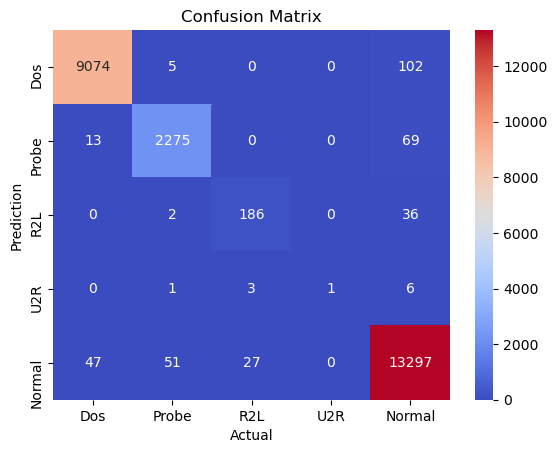

In [25]:
# Confusion matrix 
cm = confusion_matrix(y_test,y_pred_test)

# Plotting the confusion matrix 
sns.heatmap(cm,
            cmap = 'coolwarm',
            annot=True,
            fmt = "g",
            xticklabels=['Dos','Probe','R2L','U2R','Normal'],
            yticklabels=['Dos','Probe','R2L','U2R','Normal'])

plt.ylabel('Prediction')
plt.xlabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [26]:
# Compute the Multiclass ROC AUC score

lgbm_roc_score = roc_auc_score(y_test, y_proba_test, multi_class='ovr')
lgbm_roc_score

0.996515122857231

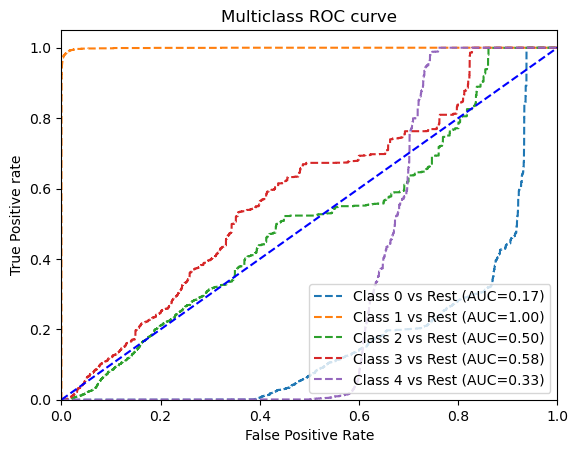

In [27]:
# roc curve for 5 classes
fpr = {}
tpr = {}
threshold ={}
n_class = 5
roc_auc = {}

for i in range(n_class): 
    fpr[i], tpr[i], threshold[i] = roc_curve(y_test, y_proba_test[:,i], pos_label = 1)
    roc_auc[i] = auc(fpr[i], tpr[i])
    # plotting    
    plt.plot(fpr[i], tpr[i], linestyle='--', label='Class {} vs Rest (AUC={:.2f})'.format(i, roc_auc[i]))

plt.plot([0,1],[0,1],'b--')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.title('Multiclass ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')
plt.legend(loc='lower right')
plt.show()  

****

In [28]:
# Predict the training time on train dataset
%time y_pred_train = lgbm_best.predict(X_train)

# printing the predictions
y_pred_train

CPU times: total: 5min 32s
Wall time: 2min 55s


array([4, 0, 0, ..., 0, 4, 4])

In [29]:
# Print the classification report for training dataset 
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     36746
           1       0.99      0.99      0.99      9299
           2       0.88      0.87      0.87       771
           3       1.00      0.83      0.91        41
           4       0.99      1.00      0.99     53921

    accuracy                           0.99    100778
   macro avg       0.97      0.94      0.95    100778
weighted avg       0.99      0.99      0.99    100778



In [30]:
def metrics(y_train, y_pred_train, y_test, y_pred_test):
    precision_train = precision_score(y_train, y_pred_train,average = 'macro')
    precision_test = precision_score(y_test, y_pred_test,average = 'macro')
    recall_train = recall_score(y_train, y_pred_train,average = 'macro')
    recall_test = recall_score(y_test, y_pred_test,average = 'macro')
    f1score_train = f1_score(y_train, y_pred_train,average = 'macro')
    f1score_test = f1_score(y_test, y_pred_test,average = 'macro')
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)

    metrics_dict = {
        "Precision (Train)": precision_train,
        "Precision (Test)": precision_test,
        "Recall (Train)": recall_train,
        "Recall (Test)": recall_test,
        "F1 Score (Train)": f1score_train,
        "F1 Score (Test)": f1score_test,
        "Accuracy (Train)": accuracy_train,
        "Accuracy (Test)": accuracy_test,
    }
    
    return metrics_dict

metrics(y_train, y_pred_train, y_test, y_pred_test)

{'Precision (Train)': 0.9730572083323548,
 'Precision (Test)': 0.962699531295851,
 'Recall (Train)': 0.935774396426081,
 'Recall (Test)': 0.7731017349060886,
 'F1 Score (Train)': 0.9528042002002832,
 'F1 Score (Test)': 0.7920790639470081,
 'Accuracy (Train)': 0.9942249300442557,
 'Accuracy (Test)': 0.98563206985513}

In [31]:
def metrics(y_train, y_pred_train, y_test, y_pred_test):
    precision_train = precision_score(y_train, y_pred_train,average = 'weighted')
    precision_test = precision_score(y_test, y_pred_test,average = 'weighted')
    recall_train = recall_score(y_train, y_pred_train,average = 'weighted')
    recall_test = recall_score(y_test, y_pred_test,average = 'weighted')
    f1score_train = f1_score(y_train, y_pred_train,average = 'weighted')
    f1score_test = f1_score(y_test, y_pred_test,average = 'weighted')
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)

    metrics_dict = {
        "Precision (Train)": precision_train,
        "Precision (Test)": precision_test,
        "Recall (Train)": recall_train,
        "Recall (Test)": recall_test,
        "F1 Score (Train)": f1score_train,
        "F1 Score (Test)": f1score_test,
        "Accuracy (Train)": accuracy_train,
        "Accuracy (Test)": accuracy_test,
    }
    
    return metrics_dict

metrics(y_train, y_pred_train, y_test, y_pred_test)

{'Precision (Train)': 0.9942152049103475,
 'Precision (Test)': 0.9856077064384163,
 'Recall (Train)': 0.9942249300442557,
 'Recall (Test)': 0.98563206985513,
 'F1 Score (Train)': 0.9942141677587977,
 'F1 Score (Test)': 0.9854418502579807,
 'Accuracy (Train)': 0.9942249300442557,
 'Accuracy (Test)': 0.98563206985513}

****

In [32]:
# Checking for overfitting

%time print('Training set score: {:.4f}'.format(lgbm_best.score(X_train, y_train)))

%time print('Test set score: {:.4f}'.format(lgbm_best.score(X_test, y_test)))

Training set score: 0.9942
CPU times: total: 5min 36s
Wall time: 3min 3s
Test set score: 0.9856
CPU times: total: 1min 22s
Wall time: 51.1 s


***

In [33]:
# Class distribution in Training dataset

class_distribution_train = pd.Series(y_train).value_counts()
print(class_distribution_train)

4    53921
0    36746
1     9299
2      771
3       41
dtype: int64


In [34]:
# Class distribution in Testing dataset

class_distribution_test = pd.Series(y_test).value_counts()
print(class_distribution_test)

4    13422
0     9181
1     2357
2      224
3       11
dtype: int64


In [35]:
# Overall Detection Rate and False Alarm Rate

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

total_tp = 0
total_fn = 0
total_fp = 0
total_tn = 0
num_classes = 5

# Iterate over each class
for i in range(num_classes): 
    # Define the positive class as class i and the negative classes as all others
    selected_class = i
    all_other_classes = [c for c in range(num_classes) if c != selected_class]

    # Calculate True Positives (TP), False Negatives (FN), False Positives (FP), and True Negatives (TN)
    TP = cm[i, i]
    total_tp += TP
    FN = cm[i, all_other_classes].sum()
    total_fn += FN
    FP = cm[all_other_classes, i].sum()
    total_fp += FP
    TN = cm[all_other_classes, all_other_classes].sum() 
    total_tn += TN

overall_detection_rate = total_tp / (total_tp + total_fn)
overall_false_alarm_rate = total_fp / (total_fp + total_tn)
print('overall_detection_rate : ', overall_detection_rate * 100)  
print('overall_false_alarm_rate : ', overall_false_alarm_rate * 100)

overall_detection_rate :  98.56320698551299
overall_false_alarm_rate :  0.3631111200272835


In [36]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Initialize dictionaries to store results for each class
detection_rates = {}
false_alarm_rates = {}
class_accuracies = {}
num_classes = 5

# Iterate over each class
for i in range(num_classes): 
    # Define the positive class as class i and the negative classes as all others
    selected_class = i
    all_other_classes = [c for c in range(num_classes) if c != selected_class]

    # Calculate True Positives (TP), False Negatives (FN), False Positives (FP), and True Negatives (TN)
    TP = cm[i, i]
    FN = cm[i, all_other_classes].sum()
    FP = cm[all_other_classes, i].sum()
    TN = cm[all_other_classes, all_other_classes].sum()

    # Calculate Detection Rate (True Positive Rate) and False Alarm Rate for class i
    detection_rate = TP / (TP + FN)
    false_alarm_rate = FP / (FP + TN)
    
    # Calculate accuracy for class i
    accuracy = (TP + TN) / (TP + TN + FP + FN)

    # Store the results in dictionaries
    detection_rates[f'Class_{i}'] = detection_rate
    false_alarm_rates[f'Class_{i}'] = false_alarm_rate
    class_accuracies[f'Class_{i}'] = accuracy

# Print the Detection Rates and False Alarm Rates for each class
for class_label, dr in detection_rates.items():
    print(f'Detection Rate for {class_label}: {dr:.4f}')
print('---------------------------------------------')

for class_label, far in false_alarm_rates.items():
    print(f'False Alarm Rate for {class_label}: {far:.4f}')
print('---------------------------------------------')

for class_label, acc in class_accuracies.items():
    print(f'Accuracy for {class_label}: {acc:.4f}')
print('---------------------------------------------')

Detection Rate for Class_0: 0.9883
Detection Rate for Class_1: 0.9652
Detection Rate for Class_2: 0.8304
Detection Rate for Class_3: 0.0909
Detection Rate for Class_4: 0.9907
---------------------------------------------
False Alarm Rate for Class_0: 0.0038
False Alarm Rate for Class_1: 0.0026
False Alarm Rate for Class_2: 0.0012
False Alarm Rate for Class_3: 0.0000
False Alarm Rate for Class_4: 0.0181
---------------------------------------------
Accuracy for Class_0: 0.9933
Accuracy for Class_1: 0.9944
Accuracy for Class_2: 0.9973
Accuracy for Class_3: 0.9996
Accuracy for Class_4: 0.9866
---------------------------------------------
